In [1]:
import h5py
import psana
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import  rotate
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit,minimize
import multiprocessing
import os
from functools import partial
import time
import sys
import argparse
from datetime import datetime
import tempfile
import XSpect.XSpect_Analysis
import XSpect.XSpect_Controller
import XSpect.XSpect_Visualization
import XSpect.XSpect_PostProcessing

import XSpect.XSpect_Diagnostics

In [ ]:
start=time.time()
xas_experiment = XSpect.XSpect_Analysis.spectroscopy_experiment(lcls_run=21, hutch='xcs', experiment_id='xcsl1004021')
xas=XSpect.XSpect_Controller.XASBatchAnalysis()
keys=['epics/ccm_E','epics/ccm_E_setpoint','tt/ttCorr','epics/lxt_ttc', 'enc/lasDelay' , 'ipm4/sum','tt/AMPL','epix_1/ROI_0_sum'] 
names=['ccm','ccm_E_setpoint','time_tool_correction','lxt_ttc'  ,'encoder','ipm', 'time_tool_ampl','epix']
xas.set_key_aliases(keys,names)
xas.add_filter('xray','ipm',100.0)
xas.add_filter('simultaneous','ipm',100.0)
xas.add_filter('simultaneous','time_tool_ampl',0.01)
xas.run_parser(['151']) # 7.5 uJ -0.5 to 2 ps
xas.mintime = -2
xas.maxtime = 10
xas.numpoints = 240
xas.scattering=False
# xas.primary_analysis_parallel_loop(4,xas_experiment)
xas.primary_analysis_loop(xas_experiment)
end=time.time()
print('Time binning: {} ps steps'.format(np.min(np.diff(xas.time_bins))))

**2D Scan**

In [2]:
start=time.time()
xas_experiment = XSpect.XSpect_Analysis.spectroscopy_experiment(lcls_run=21, hutch='xcs', experiment_id='xcsl1004021')
xas=XSpect.XSpect_Controller.XASBatchAnalysis()
keys=['epics/ccm_E','epics/ccm_E_setpoint','tt/ttCorr','epics/lxt_ttc', 'enc/lasDelay' , 'ipm4/sum','tt/AMPL','epix_1/ROI_0_sum'] 
names=['ccm','ccm_E_setpoint','time_tool_correction','lxt_ttc'  ,'encoder','ipm', 'time_tool_ampl','epix']
xas.set_key_aliases(keys,names)
xas.add_filter('xray','ipm',100.0)
xas.add_filter('simultaneous','ipm',100.0)
xas.add_filter('simultaneous','time_tool_ampl',0.01)
xas.run_parser(['298-304 307-311']) # 7.5 uJ -0.5 to 2 ps
xas.mintime = -2
xas.maxtime = 10
xas.numpoints = 240
xas.scattering=False
# xas.primary_analysis_parallel_loop(4,xas_experiment)
xas.primary_analysis_loop(xas_experiment)
end=time.time()
print('Time binning: {} ps steps'.format(np.min(np.diff(xas.time_bins))))

/sdf/home/l/lbgee/UW_2025_Talk/XSpect/XSpect/XSpect_Controller.py:124: UserWarning: If you plan on using delayed key loading for the epix then please define key_epix and friendly_name_epix. And do not load it here for risk of OOM
  warnings.warn('If you plan on using delayed key loading for the epix then please define key_epix and friendly_name_epix. And do not load it here for risk of OOM')


Time binning: 0.05020920502091997 ps steps


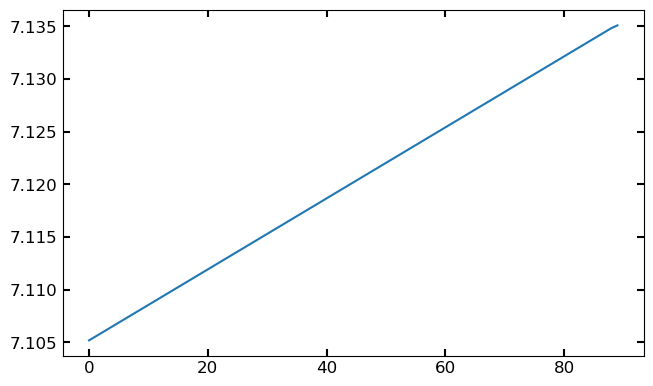

In [3]:
plt.plot(xas.analyzed_runs[0].ccm_bins)

Text(0.5, 1.0, 'xcsl1004021 298-304 307-311')

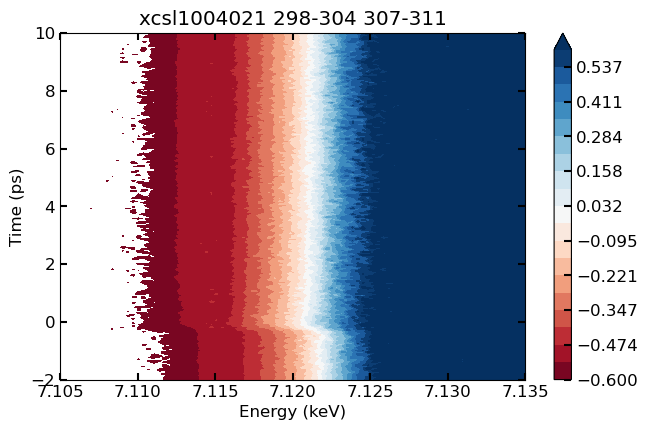

In [4]:
v=XSpect.XSpect_Visualization.XASVisualization()
v.combine_spectra(xas_analysis=xas,
                  xas_laser_key='epix_simultaneous_laser_time_energy_binned',
                  xas_key='epix_xray_not_laser_time_energy_binned',
                  norm_laser_key='ipm_simultaneous_laser_time_energy_binned',
                  norm_key='ipm_xray_not_laser_time_energy_binned',
                 interpolate=False)
v.vmin=-1.2
v.vmax=1.2
v.plot_2d_difference_spectrum(xas,vmin=v.vmin,vmax=v.vmax,alldarks=True)
plt.title('xcsl1004021 298-304 307-311')


In [5]:
v.laser_on

array([[0.11102637, 0.10919627, 0.11061381, ..., 1.58489883, 1.60421595,
        1.57893377],
       [0.11153174, 0.10743532, 0.11032633, ..., 1.56115701, 1.59227908,
        1.58170735],
       [0.11177536, 0.10693094, 0.10890413, ..., 1.61341182, 1.6061382 ,
        1.55927881],
       ...,
       [0.11269989, 0.11056702, 0.11159714, ..., 1.58550231, 1.59648465,
        1.65045894],
       [0.11368348, 0.10880476, 0.10711088, ..., 1.56137708, 1.60686535,
        1.61237003],
       [0.11026274, 0.10768798, 0.11144188, ..., 1.59919938, 1.5386471 ,
        1.60843587]])

In [6]:
v.laser_off

array([0.11017168, 0.10896262, 0.10932221, 0.10892651, 0.10954011,
       0.11020865, 0.11048138, 0.11141243, 0.11211344, 0.11246975,
       0.11361228, 0.11458989, 0.1147271 , 0.11536436, 0.1167356 ,
       0.11809873, 0.11909188, 0.12080087, 0.12122213, 0.12427768,
       0.12580213, 0.1288133 , 0.1319921 , 0.13701229, 0.14408821,
       0.15570926, 0.17352117, 0.19725995, 0.2191251 , 0.22989147,
       0.22332425, 0.2078289 , 0.20028988, 0.20217144, 0.21989328,
       0.2443792 , 0.27064933, 0.2912565 , 0.30754226, 0.32301503,
       0.34410396, 0.36923264, 0.40055188, 0.42797222, 0.46622586,
       0.49457182, 0.53183171, 0.57633906, 0.6238855 , 0.67266262,
       0.73132448, 0.79934996, 0.8721347 , 0.94050736, 1.00469943,
       1.08450634, 1.12255974, 1.18182095, 1.24159644, 1.28409651,
       1.31492467, 1.35313703, 1.37137532, 1.39762239, 1.41830371,
       1.45024518, 1.47051363, 1.50217965, 1.48142732, 1.48524853,
       1.47982179, 1.47266639, 1.45460555, 1.44545999, 1.42814

Text(0.5, 1.0, 'xcsl1004021 298-304 307-311')

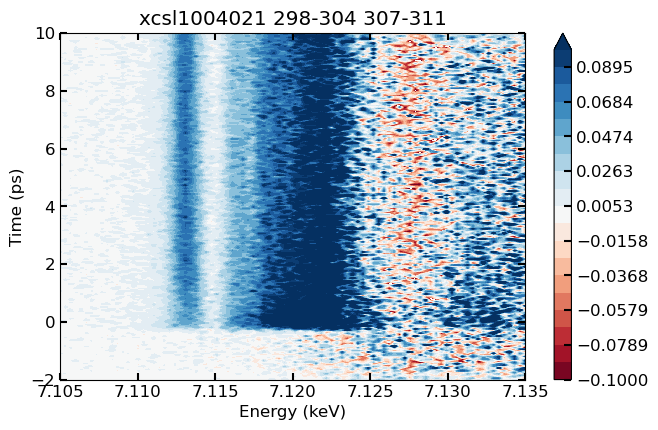

In [10]:
v=XSpect.XSpect_Visualization.XASVisualization()
v.combine_spectra(xas_analysis=xas,
                  xas_laser_key='epix_simultaneous_laser_time_energy_binned',
                  xas_key='epix_xray_not_laser_time_energy_binned',
                  norm_laser_key='ipm_simultaneous_laser_time_energy_binned',
                  norm_key='ipm_xray_not_laser_time_energy_binned',
                 interpolate=False)
v.vmin=-0.2
v.vmax=0.2
v.plot_2d_difference_spectrum(xas,vmin=v.vmin,vmax=v.vmax)
plt.title('xcsl1004021 298-304 307-311')


Text(0.5, 1.0, 'xcsl1004021 298-304 307-311')

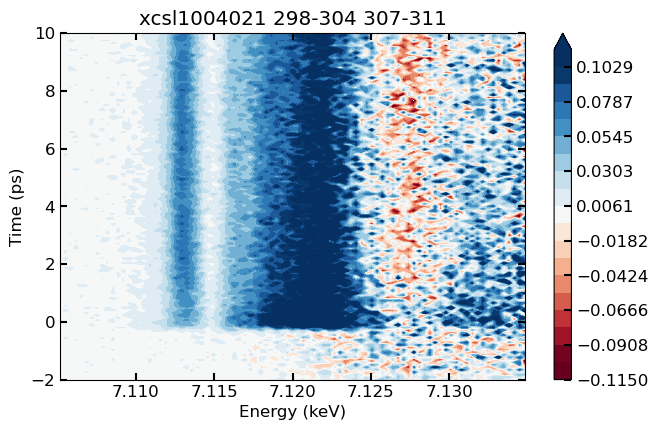

In [5]:
v=XSpect.XSpect_Visualization.XASVisualization()
v.combine_spectra(xas_analysis=xas,
                  xas_laser_key='epix_simultaneous_laser_time_energy_binned',
                  xas_key='epix_xray_not_laser_time_energy_binned',
                  norm_laser_key='ipm_simultaneous_laser_time_energy_binned',
                  norm_key='ipm_xray_not_laser_time_energy_binned',
                 interpolate=True)
v.vmin=-0.10
v.vmax=0.10
v.plot_2d_difference_spectrum(xas)
plt.title('xcsl1004021 298-304 307-311')


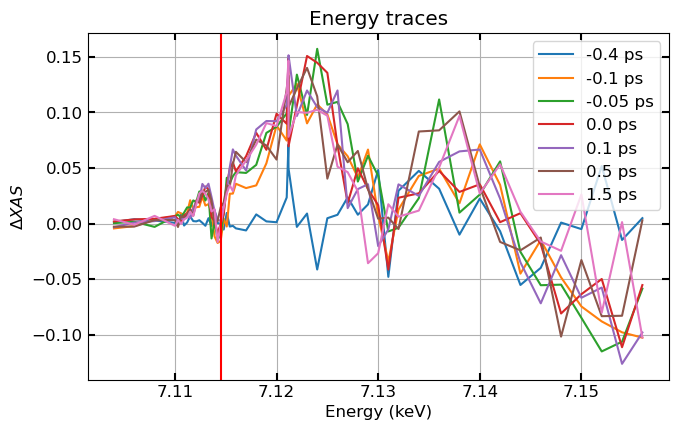

In [435]:
tlist = [-0.4, -0.1, -0.06, -0.02, 0.1, 0.5, 1.5]
# tlist = [-2, 0, 5, 20, 40]
leglist = []

for ii in tlist:
    b = np.min(np.abs(xas.time_bins-ii))
    indx = np.argmin(np.abs(xas.time_bins-ii))
    plt.plot(xas.ccm_bins, xas.difference_spectrum[indx,:])
    leglist.append('{} ps'.format(np.round(xas.time_bins[indx], decimals = 2)))
plt.legend(leglist)
plt.grid()
plt.xlabel('Energy (keV)')
plt.ylabel(r'$\Delta XAS$')
plt.title('Energy traces')
plt.axvline(7.1145, color='r')

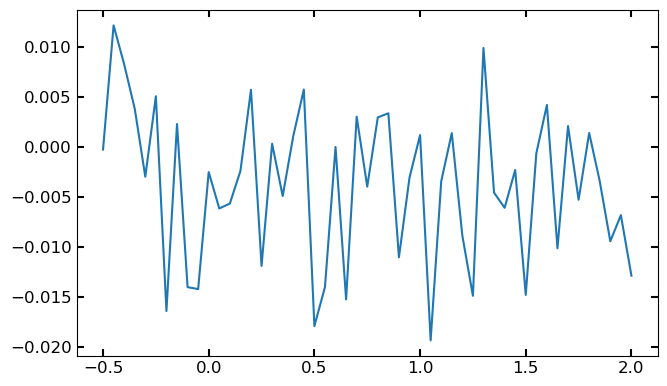

In [432]:
# # en_kin_min, en_kin_max = 7.124, 7.126
# en_kin_min, en_kin_max = 7.117, 7.119

# indx_min = np.argmin(np.abs(xas.ccm_bins - en_kin_min))
# indx_max = np.argmin(np.abs(xas.ccm_bins - en_kin_max))
# kintrace = np.nanmean(diff_svd[:,indx_min:indx_max], axis=1)
# plt.plot(xas.time_bins, kintrace)

# en_kin = 7.1185
en_kin = 7.1145

indx = np.argmin(np.abs(xas.ccm_bins - en_kin))
kintrace = xas.difference_spectrum[:,indx]
plt.plot(xas.time_bins, kintrace)


In [9]:
ana = XSpect.XSpect_PostProcessing.post_analysis()

In [421]:
xas.difference_spectrum.shape

(51, 54)

In [422]:
# np.set_printoptions(threshold=sys.maxsize)
print(xas.difference_spectrum)

[[-6.55713519e-04 -4.59163395e-05  3.97764757e-03 ...  7.34848917e-03
   5.36609479e-03 -7.24319033e-03]
 [ 1.54764448e-03  3.08549894e-03  7.44956868e-03 ... -2.53729070e-02
  -8.23009903e-04 -1.25375780e-02]
 [ 1.48132952e-03  3.89384177e-03  2.72766676e-03 ...  5.18056925e-02
  -1.47341459e-02  4.88107604e-03]
 ...
 [ 3.55457754e-03 -2.75947740e-03 -2.05382413e-03 ... -6.25308149e-02
  -5.46653793e-02 -5.75897670e-02]
 [-3.69409103e-03  2.65321155e-03  1.48315671e-03 ... -9.49814882e-02
  -5.95251502e-02 -4.61738598e-02]
 [-1.51270736e-03 -2.49475751e-03 -3.72746179e-03 ... -1.14526021e-01
  -1.39481150e-01 -3.85604978e-02]]


**SVD**

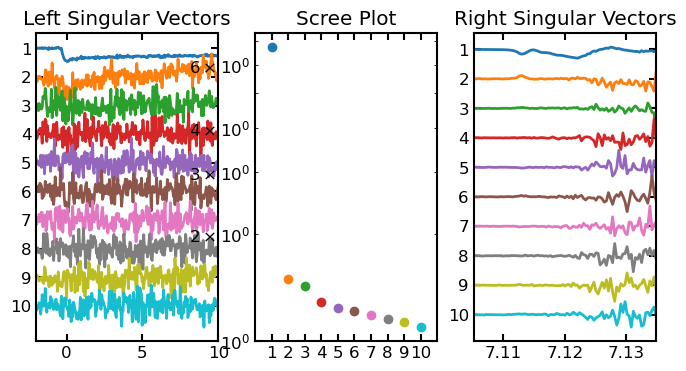

In [13]:
ncomp = 10
diff = np.nan_to_num(xas.difference_spectrum)
ana.svdplot(xas.time_bins, xas.ccm_bins, diff, ncomp)

SVD Reconstruction performed with 5 components


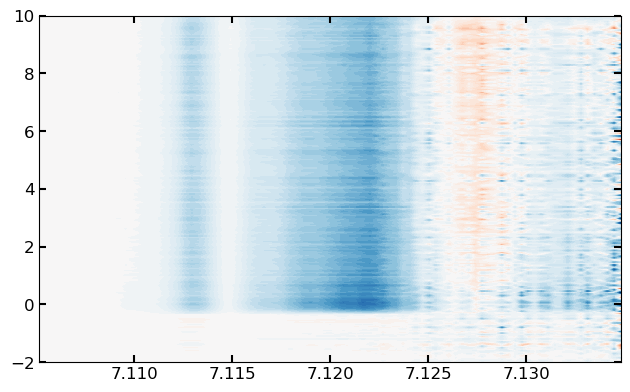

In [14]:
nsvd = 5
diff_svd = ana.svdreconstruct(diff, nsvd)

plotmax = np.max(np.abs(diff_svd))
contlevels = np.linspace(-plotmax, plotmax, 50)
plt.contourf(xas.ccm_bins, xas.time_bins, diff_svd, contlevels, cmap = 'RdBu')

Text(0.5, 1.0, 'SVD reconstructed energy traces')

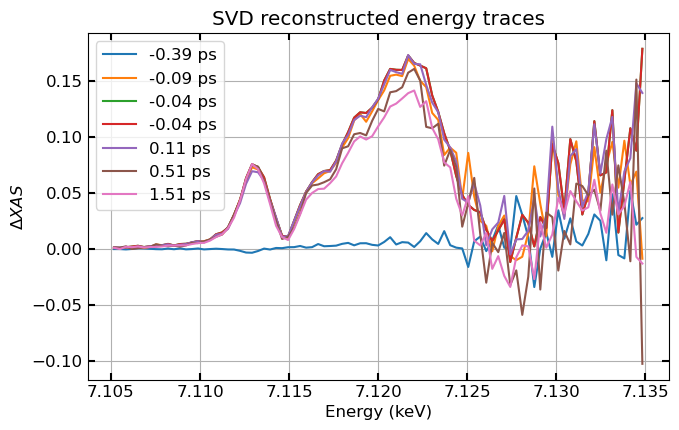

In [15]:
tlist = [-0.4, -0.1, -0.06, -0.02, 0.1, 0.5, 1.5]
# tlist = [-2, 0, 5, 10, 20]
leglist = []

for ii in tlist:
    b = np.min(np.abs(xas.time_bins-ii))
    indx = np.argmin(np.abs(xas.time_bins-ii))
    plt.plot(xas.ccm_bins, diff_svd[indx,:])
    leglist.append('{} ps'.format(np.round(xas.time_bins[indx], decimals = 2)))
plt.legend(leglist)
plt.grid()
plt.xlabel('Energy (keV)')
plt.ylabel(r'$\Delta XAS$')
plt.title('SVD reconstructed energy traces')

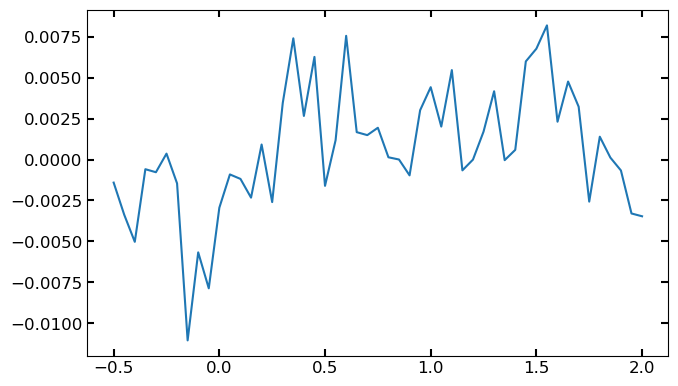

In [427]:
# en_kin_min, en_kin_max = 7.124, 7.126

# indx_min = np.argmin(np.abs(xas.ccm_bins - en_kin_min))
# indx_max = np.argmin(np.abs(xas.ccm_bins - en_kin_max))
# kintrace = np.nanmean(diff_svd[:,indx_min:indx_max], axis=1)
# plt.plot(xas.time_bins, kintrace)

en_kin = 7.118
en_kin = 7.1145

indx = np.argmin(np.abs(xas.ccm_bins - en_kin))
kintrace = diff_svd[:,indx]
plt.plot(xas.time_bins, kintrace)


**Global Kinetic Analysis**

Fit Parameters:
{'k': array([0.54460275, 0.01107891]), 'center': array([-0.23800315]), 'sigma': array([0.07255899]), 'amplitudes': array([], dtype=float64)}

Cost:
16.36098909142312

tau1: 1.8362007940508718 ps
tau2: 90.2616189358279 ps
IRF center: -0.23800315186065982 ps
IRF FWHM: 0.17086336873554656 ps


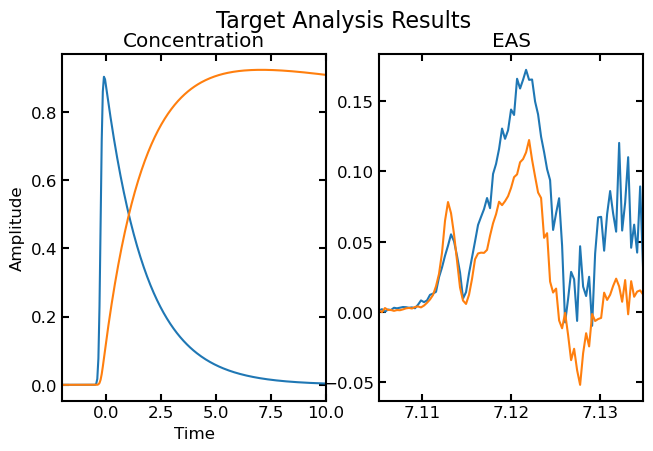

In [16]:
k_guess = [0.2, 0.001]
irf_t0_guess = [0]
irf_sigma_guess = [0.1]
# data2fit = diff_svd
data2fit = np.nan_to_num(xas.difference_spectrum)

K_guess = lambda x:np.array([(-x[0], 0), (x[0], -x[1])]) # sequential
X0_guess = [1,0] # sequential

# K_guess = lambda x:np.array([(-x[0], 0), (0, -x[1])]) # parallel
# X0_guess = [1,1] # parallel

fit, Cfit, Efit = ana.targetanalysis_run(data2fit, xas.time_bins, K_guess, k_guess, irf_t0_guess, irf_sigma_guess, X0_guess, y = xas.ccm_bins)

print('')
print('tau1: {} ps'.format(1/fit.x[0]))
print('tau2: {} ps'.format(1/fit.x[1]))
print('IRF center: {} ps'.format(fit.x[2]))
print('IRF FWHM: {} ps'.format(2*np.sqrt(2*np.log(2))*fit.x[3]))

**Overlay fit w/ Time Trace**

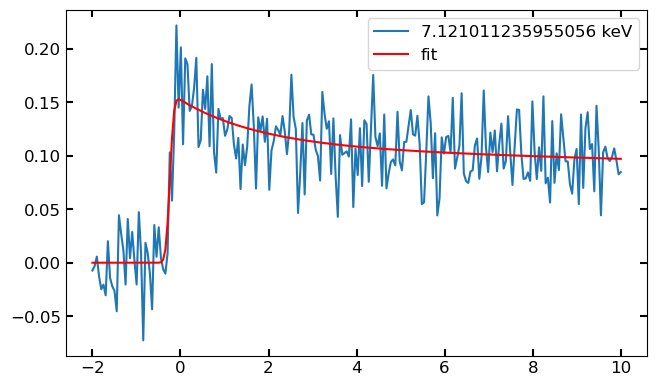

In [17]:
Afit = Cfit@np.transpose(Efit)
Afit.shape

# en_kin_min, en_kin_max = 7.120, 7.122
en_kin = 7.121

# indx_min = np.argmin(np.abs(xas.ccm_bins - en_kin_min))
# indx_max = np.argmin(np.abs(xas.ccm_bins - en_kin_max))
# kintrace_fit = np.nanmean(Afit[:,indx_min:indx_max], axis=1)
# kintrace = np.nanmean(data2fit[:,indx_min:indx_max], axis=1)
indx = np.argmin(np.abs(xas.ccm_bins - en_kin))
kintrace_fit = Afit[:,indx]
kintrace = data2fit[:,indx]
plt.plot(xas.time_bins, kintrace)
plt.plot(xas.time_bins, kintrace_fit, color='r')
# plt.legend(['{} keV'.format((en_kin_min+en_kin_max)/2), 'fit'])
plt.legend(['{} keV'.format(xas.ccm_bins[indx]), 'fit'])

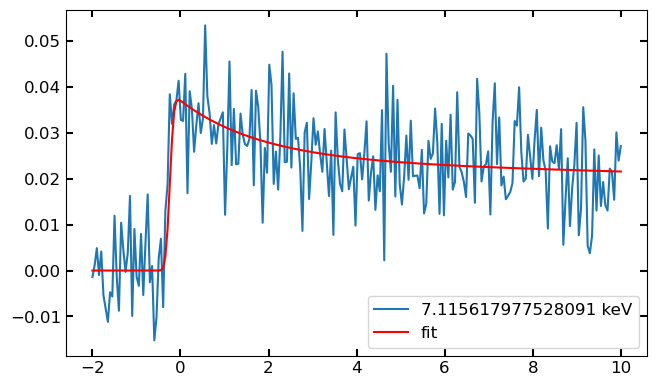

In [19]:
Afit = Cfit@np.transpose(Efit)
Afit.shape

# en_kin = 7.118
en_kin = 7.1155

indx = np.argmin(np.abs(xas.ccm_bins - en_kin))
kintrace_fit = Afit[:,indx]
kintrace = data2fit[:,indx]
plt.plot(xas.time_bins, kintrace)
plt.plot(xas.time_bins, kintrace_fit, color='r')
plt.legend(['{} keV'.format(xas.ccm_bins[indx]), 'fit'])

Fit Parameters:
{'k': array([0.04418094]), 'center': array([-0.2609454]), 'sigma': array([0.05478765]), 'amplitudes': array([], dtype=float64)}

Cost:
17.00761473430441

tau1: 22.634193803235238 ps
IRF center: -0.26094540224233087 ps
IRF FWHM: 0.12901505816654685 ps


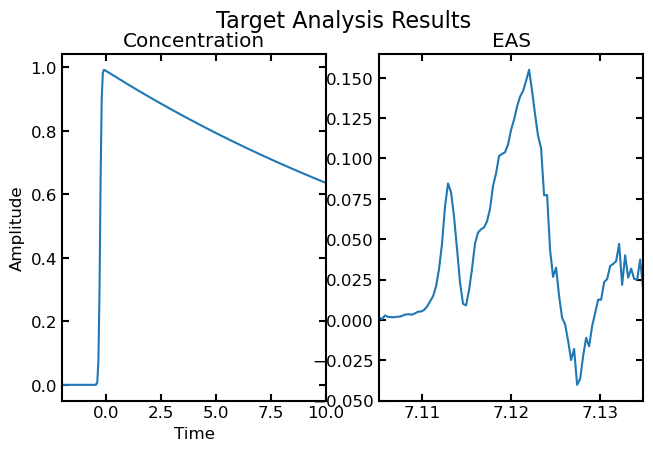

In [20]:
k_guess = [0.001]
irf_t0_guess = [0]
irf_sigma_guess = [0.1]
# data2fit = diff_svd
data2fit = np.nan_to_num(xas.difference_spectrum)

K_guess = lambda x:np.array([-x[0]])
X0_guess = [1]

fit, Cfit, Efit = ana.targetanalysis_run(data2fit, xas.time_bins, K_guess, k_guess, irf_t0_guess, irf_sigma_guess, X0_guess, y = xas.ccm_bins)
print('')
print('tau1: {} ps'.format(1/fit.x[0]))
print('IRF center: {} ps'.format(fit.x[1]))
print('IRF FWHM: {} ps'.format(2*np.sqrt(2*np.log(2))*fit.x[2]))

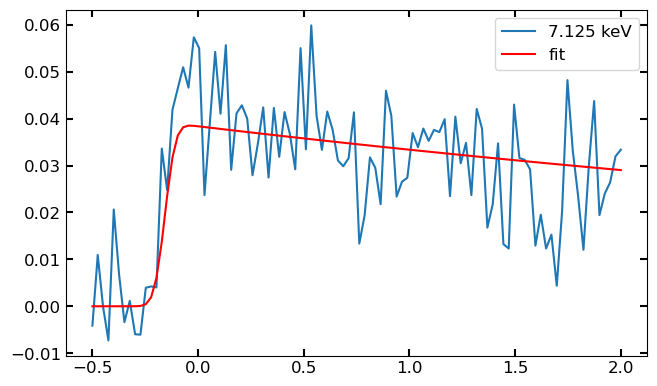

In [322]:
Afit = Cfit@np.transpose(Efit)
Afit.shape

en_kin_min, en_kin_max = 7.124, 7.126

indx_min = np.argmin(np.abs(xas.ccm_bins - en_kin_min))
indx_max = np.argmin(np.abs(xas.ccm_bins - en_kin_max))
kintrace_fit = np.nanmean(Afit[:,indx_min:indx_max], axis=1)
kintrace = np.nanmean(data2fit[:,indx_min:indx_max], axis=1)
plt.plot(xas.time_bins, kintrace)
plt.plot(xas.time_bins, kintrace_fit, color='r')
plt.legend(['{} keV'.format((en_kin_min+en_kin_max)/2), 'fit'])

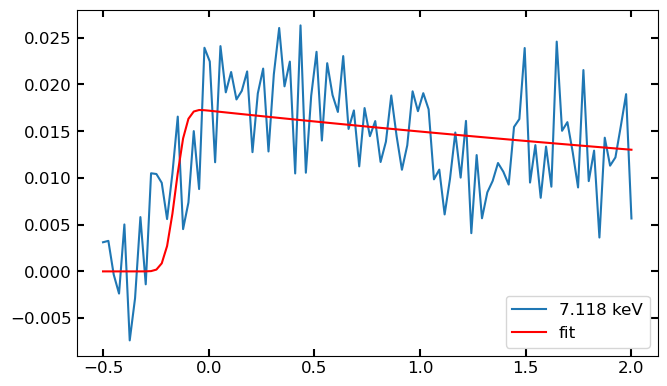

In [323]:
Afit = Cfit@np.transpose(Efit)
Afit.shape

en_kin = 7.118

indx = np.argmin(np.abs(xas.ccm_bins - en_kin))
kintrace_fit = Afit[:,indx]
kintrace = data2fit[:,indx]
plt.plot(xas.time_bins, kintrace)
plt.plot(xas.time_bins, kintrace_fit, color='r')
plt.legend(['{} keV'.format(en_kin), 'fit'])

<font size=5>XAS Analysis and Visualization Test</font>

**1D XAS**

In [2]:
start=time.time()
xas_experiment = XSpect.XSpect_Analysis.spectroscopy_experiment(lcls_run=22, hutch='xcs', experiment_id='xcsl1030422')
xas=XSpect.XSpect_Controller.XASBatchAnalysis_1D_ccm()
keys=['epics/ccm_E','epicsUser/ccm_E_setpoint','tt/ttCorr','epics/lxt_ttc', 'enc/lasDelay' , 'ipm4/sum','tt/AMPL','epix_2/ROI_0_sum'] 
names=['ccm','ccm_E_setpoint','time_tool_correction','lxt_ttc'  ,'encoder','ipm', 'time_tool_ampl','epix']
xas.set_key_aliases(keys,names)
xas.add_filter('xray','ipm',500.0)
xas.add_filter('simultaneous','ipm',500.0)
# xas.add_filter('simultaneous','time_tool_ampl',0.01)
xas.run_parser(['255'])
# xas.primary_analysis_parallel_loop(4,xas_experiment)
xas.primary_analysis_loop(xas_experiment)
end=time.time()

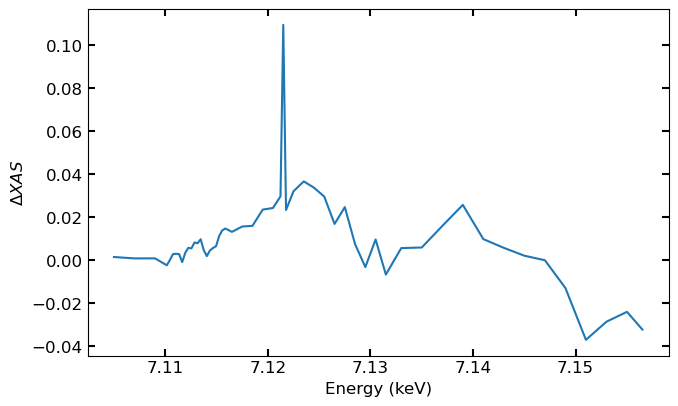

In [3]:
v=XSpect.XSpect_Visualization.XASVisualization()
v.combine_spectra(xas_analysis=xas,
                  xas_laser_key='epix_simultaneous_laser_energy_binned',
                  xas_key='epix_xray_not_laser_energy_binned',
                  norm_laser_key='ipm_simultaneous_laser_energy_binned',
                  norm_key='ipm_xray_not_laser_energy_binned')
v.plot_1d_difference_spectrum(xas)

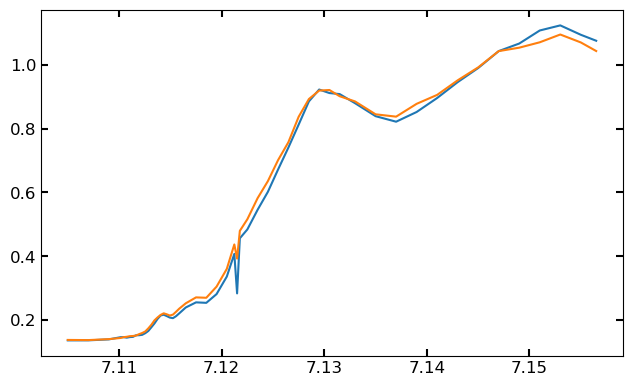

In [12]:
energy = xas.analyzed_runs[0].ccm_bins[:]
lasoff = xas.analyzed_runs[0].epix_xray_not_laser_energy_binned[:]
lason = xas.analyzed_runs[0].epix_simultaneous_laser_energy_binned[:]
ipmoff = xas.analyzed_runs[0].ipm_xray_not_laser_energy_binned[:]
ipmon = xas.analyzed_runs[0].ipm_simultaneous_laser_energy_binned[:]
# plt.plot(energy, lasoff)
# plt.plot(energy, lason)
# plt.plot(energy, ipmoff)
# plt.plot(energy, ipmon)
plt.plot(energy, lasoff/ipmoff)
plt.plot(energy, lason/ipmon)

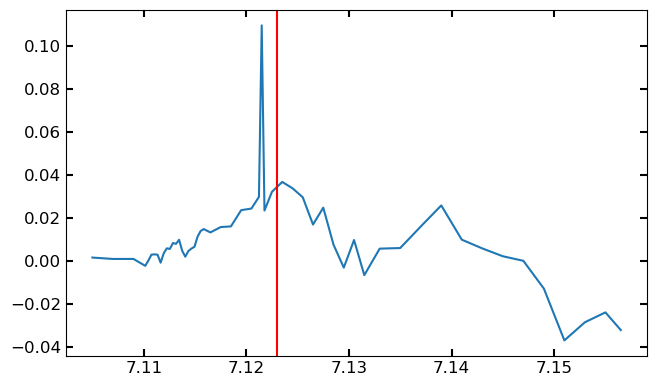

In [14]:
diff = (lason/ipmon) - (lasoff/ipmoff)
plt.plot(energy, diff)
plt.axvline(7.123, color = 'r')

**1D Time Scan**

In [4]:
start=time.time()
xas_experiment = XSpect.XSpect_Analysis.spectroscopy_experiment(lcls_run=22, hutch='xcs', experiment_id='xcsl1030422')
xas=XSpect.XSpect_Controller.XASBatchAnalysis_1D_time()
keys=['epics/ccm_E','epicsUser/ccm_E_setpoint','tt/ttCorr','epics/lxt_ttc', 'enc/lasDelay' , 'ipm4/sum','tt/AMPL','epix_2/ROI_0_sum'] 
names=['ccm','ccm_E_setpoint','time_tool_correction','lxt_ttc'  ,'encoder','ipm', 'time_tool_ampl','epix']
xas.set_key_aliases(keys,names)
xas.add_filter('xray','ipm',500.0)
xas.add_filter('simultaneous','ipm',500.0)
xas.add_filter('simultaneous','time_tool_ampl',0.01)
xas.run_parser(['211-213'])
xas.mintime = -1
xas.maxtime = 1
xas.numpoints = 20
# xas.primary_analysis_parallel_loop(4,xas_experiment)
xas.primary_analysis_loop(xas_experiment)
end=time.time()

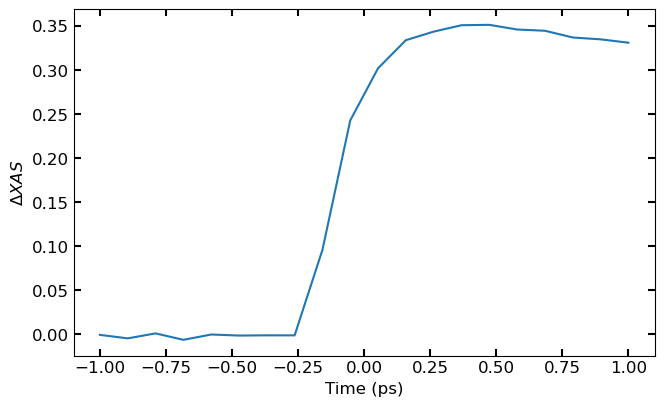

In [5]:
v=XSpect.XSpect_Visualization.XASVisualization()
v.combine_spectra(xas_analysis=xas,
                  xas_laser_key='epix_simultaneous_laser_time_binned',
                  xas_key='epix_xray_not_laser_time_binned',
                  norm_laser_key='ipm_simultaneous_laser_time_binned',
                  norm_key='ipm_xray_not_laser_time_binned')
v.plot_1d_difference_time(xas)